In [4]:
using ITensors, ITensorMPS
using ITransverse
using ITensorExpMPO
using ITensors: Algorithm
using Plots
using Plots.PlotMeasures
using ProgressMeter
ProgressMeter.ijulia_behavior(:clear)
using JLD2


using LsqFit

using Revise
includet("main.jl")

In [5]:
# Global Parameters
N = 40
target_times = collect(0.5 : 1.0 : 6.5) 
p = 0.5
lambda = 1.0
dt = 0.05
cutoff = 1e-14
maxdim = 256

# Setup finite chain and shared initial state
sites = siteinds("S=1/2", N)
psi0 = complex(MPS(sites, "X+"))

40-element MPS:
 ((dim=2|id=406|"S=1/2,Site,n=1"), (dim=1|id=791|"Link,l=1"))
 ((dim=1|id=791|"Link,l=1"), (dim=2|id=954|"S=1/2,Site,n=2"), (dim=1|id=273|"Link,l=2"))
 ((dim=1|id=273|"Link,l=2"), (dim=2|id=631|"S=1/2,Site,n=3"), (dim=1|id=638|"Link,l=3"))
 ((dim=1|id=638|"Link,l=3"), (dim=2|id=528|"S=1/2,Site,n=4"), (dim=1|id=220|"Link,l=4"))
 ((dim=1|id=220|"Link,l=4"), (dim=2|id=793|"S=1/2,Site,n=5"), (dim=1|id=719|"Link,l=5"))
 ((dim=1|id=719|"Link,l=5"), (dim=2|id=833|"S=1/2,Site,n=6"), (dim=1|id=684|"Link,l=6"))
 ((dim=1|id=684|"Link,l=6"), (dim=2|id=56|"S=1/2,Site,n=7"), (dim=1|id=146|"Link,l=7"))
 ((dim=1|id=146|"Link,l=7"), (dim=2|id=706|"S=1/2,Site,n=8"), (dim=1|id=808|"Link,l=8"))
 ((dim=1|id=808|"Link,l=8"), (dim=2|id=794|"S=1/2,Site,n=9"), (dim=1|id=745|"Link,l=9"))
 ((dim=1|id=745|"Link,l=9"), (dim=2|id=150|"S=1/2,Site,n=10"), (dim=1|id=366|"Link,l=10"))
 ⋮
 ((dim=1|id=248|"Link,l=31"), (dim=2|id=440|"S=1/2,Site,n=32"), (dim=1|id=42|"Link,l=32"))
 ((dim=1|id=42|"Link,l=32"

In [9]:
# TVDP 
H_mpo = MPO(benchmark_opsum(N, lambda, p), sites)
psi_t_TDVP = deepcopy(psi0)
rate_TDVP = Float64[]
current_t = 0.0

@showprogress "TDVP Evolution..." for T in target_times
    steps = round(Int, (T - current_t) / dt)
    for _ in 1:steps
        global psi_t_TDVP = tdvp(H_mpo, -im * dt, psi_t_TDVP; cutoff=cutoff, maxdim=maxdim, nsite=2)
        normalize!(psi_t_TDVP) 
    end
    global current_t = T
    
    G_TDVP = inner(psi0, psi_t_TDVP)
    push!(rate_TDVP, -log(max(abs(G_TDVP), 1e-50)) / N)
    GC.gc()
end

jldsave("rate_TDVP.jld2"; rate_TDVP)

psi_t_TDVP = nothing
H_mpo = nothing
GC.gc()

TDVP Evolution... 100%|██████████████████████████████████| Time: 11:02:44


In [7]:
# VD2 
U_VD2 = expH_benchmark(sites, lambda, p; dt=dt, mpo_alg="VD2")
psi_t_VD2 = deepcopy(psi0)
rate_VD2 = Float64[]
current_t = 0.0

@showprogress "VD2 Evolution..." for T in target_times
    steps = round(Int, (T - current_t) / dt)
    for _ in 1:steps
        global psi_t_VD2 = apply(U_VD2, psi_t_VD2; cutoff=cutoff, maxdim=maxdim)
        normalize!(psi_t_VD2) 
    end
    global current_t = T
    
    G_VD2 = inner(psi0, psi_t_VD2)
    push!(rate_VD2, -log(max(abs(G_VD2), 1e-50)) / N)
    GC.gc()
end

jldsave("rate_VD2.jld2"; rate_VD2)

psi_t_VD2 = nothing
U_VD2 = nothing
GC.gc()

VD2 Evolution... 100%|███████████████████████████████████| Time: 0:34:12


In [8]:
# WII
U_WII = expH_benchmark(sites, lambda, p; dt=dt, mpo_alg="WII")
psi_t_WII = deepcopy(psi0)
rate_WII = Float64[]
current_t = 0.0

@showprogress "WII Evolution..." for T in target_times
    steps = round(Int, (T - current_t) / dt)
    for _ in 1:steps
        global psi_t_WII = apply(U_WII, psi_t_WII; cutoff=cutoff, maxdim=maxdim)
        normalize!(psi_t_WII) 
    end
    global current_t = T
    
    G_WII = inner(psi0, psi_t_WII)
    push!(rate_WII, -log(max(abs(G_WII), 1e-50)) / N)
    GC.gc()
end

jldsave("rate_WII.jld2"; rate_WII)

psi_t_WII = nothing
U_WII = nothing
GC.gc()

WII Evolution... 100%|███████████████████████████████████| Time: 0:09:48


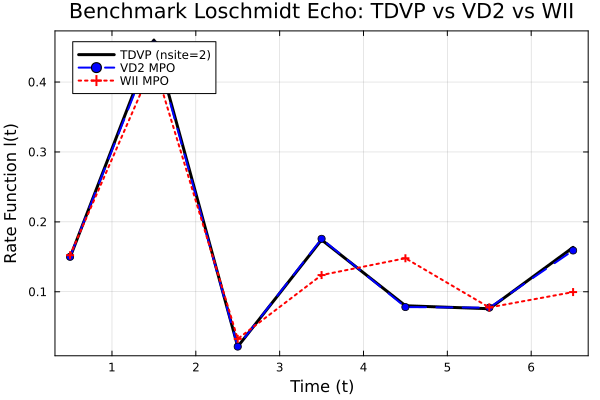

In [10]:
target_times = collect(0.5 : 1.0 : 6.5) 

# Load data safely from the JLD2 files
r_TDVP = load("rate_TDVP.jld2", "rate_TDVP")
r_VD2  = load("rate_VD2.jld2", "rate_VD2")
r_WII  = load("rate_WII.jld2", "rate_WII")

comparison_plot = plot(
    title="Benchmark Loschmidt Echo: TDVP vs VD2 vs WII",
    xlabel="Time (t)", 
    ylabel="Rate Function l(t)", 
    grid=true, framestyle=:box, legend=:topleft
)

plot!(comparison_plot, target_times, r_TDVP, label="TDVP (nsite=2)", lw=3, color=:black)
plot!(comparison_plot, target_times, r_VD2, label="VD2 MPO", lw=2, marker=:circle, ls=:dash, color=:blue)
plot!(comparison_plot, target_times, r_WII, label="WII MPO", lw=2, marker=:cross, ls=:dot, color=:red)

---

Let's try to benchmark the transverse contraction

In [ ]:
function compute_benchmark_entropies(
    mpo_generator::Function, target_T::Float64;
    p::Float64=0.0, lambda::Float64=1.0,
    dt::Float64=0.1, cutoff::Float64=1e-12, maxdim::Int=256, 
    alg::String="RTM", eps_converged::Float64=1e-6, nbeta::Int=4,
    MPO_alg::String="VD2"
)
    Ntime_steps = round(Int, target_T / dt)
    Nsteps = Ntime_steps + nbeta
    dbeta = -im * dt

    s = Index(2, "S=1/2")
    # Initial state |Psi0>
    init_state = complex(state(s, "X+"))  # |X+> state in Z basis

    RECIPES = Dict(
        "WI"  => BenchmarkWI(),
        "WII" => BenchmarkWII(),
        "VD2" => BenchmarkVD2()
    )
    
    # Build tMPO blocks
    mp_bench = BenchmarkParams(lambda=lambda, p=p, phys_site=s)
    tp = tMPOParams(
        mp=mp_bench; 
        dt=dt, 
        nbeta=nbeta, 
        scheme=RECIPES[MPO_alg],
        dbeta=dbeta, 
        bl=init_state
    )
    b = FwtMPOBlocks(tp)
    
    # Power Method Params
    pm_params = PMParams(;
        truncp = (; cutoff=cutoff, maxdim=maxdim, alg=alg), 
        opt_method = :nosym, 
        cutoffs = [cutoff], 
        maxdims = 2:2:maxdim, 
        itermax = 5000, 
        eps_converged = eps_converged, 
        normalization = "overlap",
        stuck_after = 200,
        compute_fidelity = true
    )

    # Dynamically determine spatial bond dimension
    spatial_bond_dim = dim(inds(b.Wc, "Site,time")[1])

    # The virtual links of the spatial MPO become the physical sites of the temporal MPS
    time_sites  = addtags(siteinds(spatial_bond_dim, Nsteps; conserve_qns=false), "time")

    # Build the transverse Transfer Matrix
    mpo         = fw_tMPO(b, time_sites, tr=init_state)
    # Temporal boundary (random so that it overlaps with the dominant eigenvector)
    start_mps   = fw_tMPS(b, time_sites; tr=init_state, LR=:right)
    for i in eachindex(start_mps)
        tensor_inds = inds(start_mps[i])
        
        start_mps[i] = randomITensor(ComplexF64, tensor_inds)
    end
    normalize!(start_mps)

    # Run Power Method
    psi_L, psi_R, pm_info = ITransverse.powermethod_lr(start_mps, mpo, mpo, pm_params)

    # Normalize just in case
    norm = overlap_noconj(psi_L, psi_R)
    psi_L ./= sqrt(norm)
    psi_R ./= sqrt(norm)

    # Calculate entropy profiles (real and imaginary)
    p_r2_real = real.(ITransverse.gen_renyi2(psi_L, psi_R))
    p_r2_imag = imag.(ITransverse.gen_renyi2(psi_L, psi_R))

    bonds = 1:length(p_r2_real)

    return bonds, p_r2_real, p_r2_imag, psi_L, psi_R, mpo
end

compute_benchmark_entropies (generic function with 1 method)

In [ ]:
mpo_generator = expH_benchmark
alg = "RTM"
eps_converged = 1e-6
nbeta = 4
MPO_alg = "VD2"

rate_trans_VD2 = Float64[]

@showprogress "Transverse Contraction ($MPO_alg)..." for T in target_times
    bonds, r2_re, r2_im, psi_L, psi_R, mpo = compute_benchmark_entropies(
        mpo_generator, T; 
        lambda=lambda, p=p, dt=dt, cutoff=cutoff, maxdim=maxdim, 
        alg=alg, eps_converged=eps_converged, nbeta=nbeta, MPO_alg=MPO_alg
    )

    overlap_0 = overlap_noconj(psi_L, psi_R)
    
    if isnan(abs(overlap_0)) || abs(overlap_0) < 1e-25
        push!(rate_trans_VD2, NaN)
    else
        Lambda_0 = ITransverse.expval_LR(psi_L, mpo, psi_R) / overlap_0
        push!(rate_trans_VD2, -log(abs(Lambda_0)))
    end
    
    psi_L = nothing
    psi_R = nothing
    mpo = nothing
    GC.gc()
end

jldsave("rate_trans_VD2.jld2"; rate_trans_VD2)

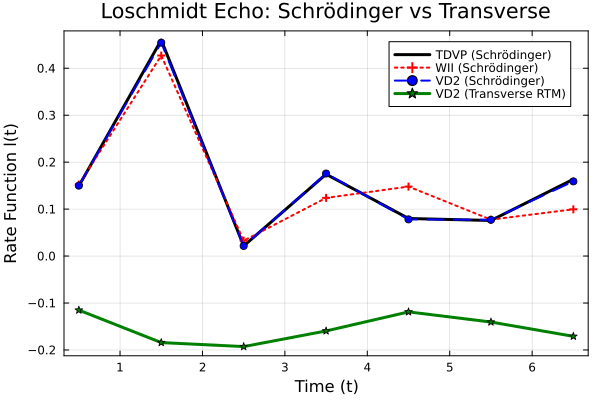

In [21]:
r_TDVP       = load("rate_TDVP.jld2", "rate_TDVP")
r_VD2_schrod = load("rate_VD2.jld2", "rate_VD2")
r_WII_schrod = load("rate_WII.jld2", "rate_WII")
r_VD2_trans  = load("rate_trans_VD2.jld2", "rate_trans_VD2")

comparison_plot = plot(
    title="Loschmidt Echo: Schrödinger vs Transverse",
    xlabel="Time (t)", 
    ylabel="Rate Function l(t)", 
    grid=true, framestyle=:box, legend=:topright
)

plot!(comparison_plot, target_times, r_TDVP, label="TDVP (Schrödinger)", lw=3, color=:black)
plot!(comparison_plot, target_times, r_WII_schrod, label="WII (Schrödinger)", lw=2, marker=:cross, ls=:dot, color=:red)
plot!(comparison_plot, target_times, r_VD2_schrod, label="VD2 (Schrödinger)", lw=2, marker=:circle, ls=:dash, color=:blue)

plot!(comparison_plot, target_times, r_VD2_trans, label="VD2 (Transverse RTM)", lw=3, marker=:star, color=:green)

display(comparison_plot)